# 2 — From modes to IMF features

Notebook 1 established that the solver works and which `alpha` to trust. This one does
the actual job: cut the recordings into windows, decompose each window into `K` IMFs,
and reduce each IMF to a vector of numbers a model can learn from.

The output is a single `.npz` — the artefact everything downstream consumes, including
the quantum stage.

**The one rule that governs this notebook:** every window carries its `record_id`, and
that id travels with it forever. Segments from the same recording are near-duplicates;
if they are allowed to fall on both sides of a train/test split, the model learns to
recognise the *patient* rather than the pathology. On this dataset that is worth about
+0.12 macro-F1 of pure illusion, which is demonstrated in notebook 3.

In [1]:
# --- Bootstrap: works unchanged in VS Code, plain Jupyter, and Google Colab ----------
import os, sys, subprocess

def _bootstrap():
    try:
        import ecgvmd  # noqa: F401
        return os.path.dirname(os.path.dirname(os.path.abspath(ecgvmd.__file__)))
    except ImportError:
        pass
    d = os.path.abspath(os.getcwd())
    for _ in range(4):
        if os.path.isdir(os.path.join(d, "ecgvmd")):
            sys.path.insert(0, d); return d
        d = os.path.dirname(d)
    for cand in ("/content/test-ecg-training", "/content/drive/MyDrive/test-ecg-training"):
        if os.path.isdir(os.path.join(cand, "ecgvmd")):
            sys.path.insert(0, cand); return cand
    try:
        from google.colab import files
        print("Upload ecgvmd_bundle.zip (make it with: python make_colab_bundle.py)")
        up = files.upload()
        import zipfile
        with zipfile.ZipFile(next(iter(up))) as z:
            z.extractall("/content")
        sys.path.insert(0, "/content"); return "/content"
    except ImportError:
        raise ImportError("Could not locate the ecgvmd package.")

IN_COLAB = "google.colab" in sys.modules or os.path.isdir("/content")
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "-q", "install",
                    "numpy", "scipy", "scikit-learn", "pandas", "matplotlib"], check=False)
ROOT = _bootstrap(); os.chdir(ROOT)
print("project root:", ROOT)

project root: /mnt/d/Projects/test-ecg-training


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ecgvmd as E
from ecgvmd import CFG, CLASS_ORDER, CLASS_COLORS

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "figure.facecolor": "white",
    "axes.titlesize": 10, "legend.frameon": False,
})

# ==================================================================================
#  THE ONE CELL TO EDIT
# ==================================================================================
FAST = True          # True  -> 10 windows/record (~3 min).  Use this first.
                     # False -> every window (~40 min on one core).
SEG_MODE = "fixed"   # "fixed" grid, or "beat" (windows centred on R-peaks)
KEEP_IMFS = True     # also store the raw (B, K, N) mode tensor for the deep model

cfg = CFG.replace(
    seg_mode=SEG_MODE,
    n_per_record=10 if FAST else 0,
    K=8,
    alpha=2000.0,       # <- set from the conclusion of notebook 1
    max_iter=500,       # <- likewise
)
print(cfg.summary())
print("cache signature:", cfg.signature())

fs=128 Hz | window=500 (3.91 s) | seg_mode=fixed | K=8 | alpha=2000 | dc=True | max_iter=500
cache signature: fixed_K8_a2000_L500_it500_eeb2053b


## 2.1 The recordings

162 records, 8.5 minutes each at 128 Hz, three classes: **ARR** (arrhythmia),
**CHF** (congestive heart failure), **NSR** (normal sinus rhythm).

Two things about this file are worth knowing before you touch it:

1. **It is stored sorted by class** — 96 ARR, then 30 CHF, then 36 NSR. `data[:10]`
   is not a sample, it is ten arrhythmia records. Use
   `stratified_record_sample()` when you want a subset.
2. **The three classes come from three different source databases.** Any feature that
   reflects recording equipment rather than physiology will separate them beautifully
   and mean nothing. Section 2.6 and notebook 3 come back to this.

In [3]:
ds = E.load_ecgdata()
print(ds)
print()
rec_df = pd.DataFrame({
    "label": ds.labels,
    "std": ds.data.std(1),
    "ptp": np.ptp(ds.data, axis=1),
    "hr_bpm": [E.heart_rate(ds.data[i], ds.fs) for i in range(ds.n_records)],
})
print(rec_df.groupby("label").agg(["mean", "std"]).round(3).to_string())

ECGDataset(162 records x 65536 samples = 8.5 min each @ 128 Hz, {'ARR': 96, 'CHF': 30, 'NSR': 36})

         std           ptp         hr_bpm        
        mean    std   mean    std    mean     std
label                                            
ARR    0.322  0.176  3.709  1.680  76.090  15.328
CHF    0.493  0.437  5.266  3.587  94.145  17.330
NSR    0.288  0.129  3.468  0.947  87.551  12.827


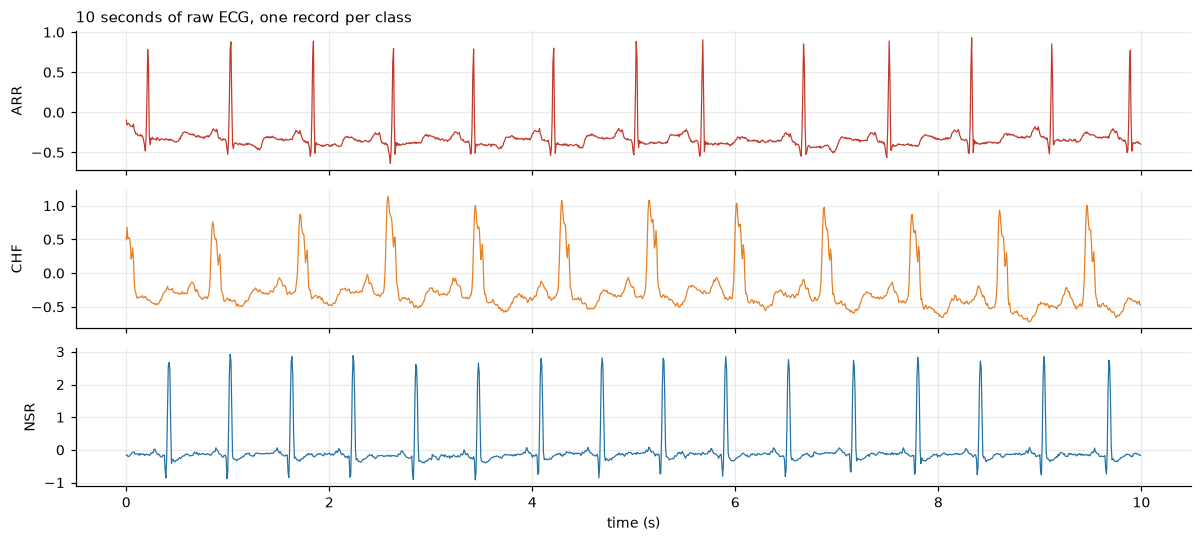

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 5), sharex=True)
tt = np.arange(int(10 * ds.fs)) / ds.fs
for ax, cls in zip(axes, CLASS_ORDER):
    i = np.where(ds.labels == cls)[0][0]
    ax.plot(tt, ds.data[i, :len(tt)], lw=0.8, color=CLASS_COLORS[cls])
    ax.set_ylabel(cls)
axes[0].set_title("10 seconds of raw ECG, one record per class", loc="left")
axes[-1].set_xlabel("time (s)")
fig.tight_layout(); plt.show()

## 2.2 Segmentation

Two options, and they are a real trade-off rather than a right answer:

| | fixed grid | beat-aligned |
|---|---|---|
| windows | every 500 samples | centred on detected R-peaks |
| uses all data | yes | no — inter-beat gaps are dropped |
| QRS phase | arbitrary | identical across windows |
| needs | nothing | an R-peak detector that must work |

Beat alignment makes morphology comparable across samples, which helps
shape-sensitive features. Fixed grid keeps rhythm information that beat-centring
partly destroys, and cannot fail. Switch with `SEG_MODE` above.

First, does the R-peak detector work? The heart rates it produces should be
physiological, and should differ by class in the expected direction.

In [5]:
for cls in CLASS_ORDER:
    idx = np.where(ds.labels == cls)[0][:12]
    hr = np.array([E.heart_rate(ds.data[i], ds.fs) for i in idx])
    print(f"{cls}: median HR {np.nanmean(hr):5.1f} bpm  (n={np.isfinite(hr).sum()})")

ARR: median HR  69.0 bpm  (n=12)
CHF: median HR  92.1 bpm  (n=12)
NSR: median HR  91.3 bpm  (n=12)


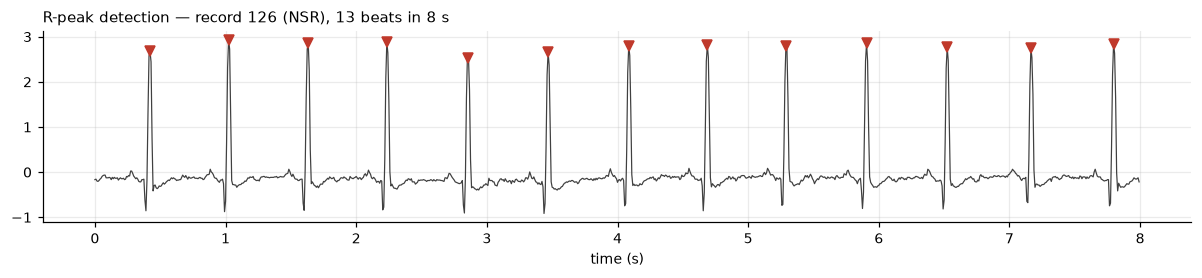

In [6]:
i = np.where(ds.labels == "NSR")[0][0]
seg = ds.data[i, :int(8 * ds.fs)]
pk = E.detect_r_peaks(seg, ds.fs)
fig, ax = plt.subplots(figsize=(11, 2.6))
ax.plot(np.arange(len(seg)) / ds.fs, seg, lw=0.8, color="0.25")
ax.plot(pk / ds.fs, seg[pk], "v", ms=6, color="#c0392b")
ax.set_title(f"R-peak detection — record {i} (NSR), {len(pk)} beats in 8 s", loc="left")
ax.set_xlabel("time (s)"); fig.tight_layout(); plt.show()

In [7]:
t0 = time.time()
W, y, groups = E.segment(ds, cfg)
print(f"\n{W.shape[0]} windows x {W.shape[1]} samples "
      f"from {len(np.unique(groups))} records  [{time.time()-t0:.0f} s]")
print("class balance:", dict(zip(*np.unique(y, return_counts=True))))
print("\nWindows are z-scored individually: the model should key on morphology,")
print("not on the recording gain of whichever database the record came from.")


1620 windows x 500 samples from 162 records  [0 s]
class balance: {np.str_('ARR'): np.int64(960), np.str_('CHF'): np.int64(300), np.str_('NSR'): np.int64(360)}

Windows are z-scored individually: the model should key on morphology,
not on the recording gain of whichever database the record came from.


## 2.3 What the IMFs look like on real ECG

One window per class, decomposed into `K` modes. Mode 1 is pinned at 0 Hz by `dc=True`
and absorbs baseline drift; the rest sort themselves by ascending centre frequency.

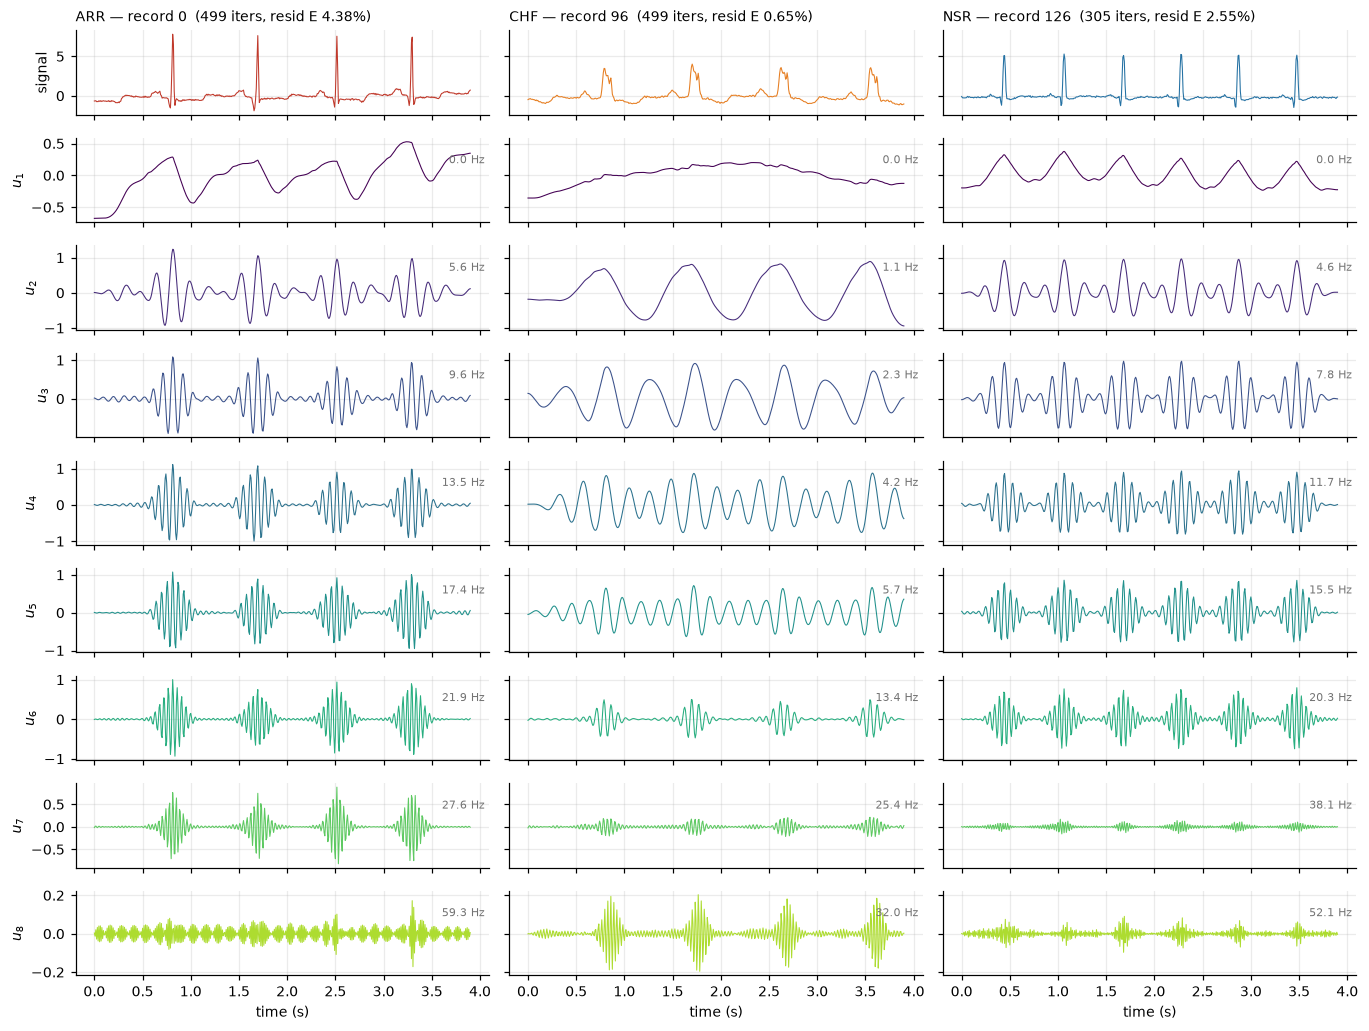

In [8]:
examples = {}
for cls in CLASS_ORDER:
    sel = np.where(y == cls)[0][2]
    r = E.vmd(W[sel], alpha=cfg.alpha, K=cfg.K, dc=cfg.dc, tol=cfg.tol,
              max_iter=cfg.max_iter, fs=cfg.fs)
    examples[cls] = (W[sel], r, groups[sel])

t = np.arange(cfg.seg_len) / cfg.fs
fig, axes = plt.subplots(cfg.K + 1, 3, figsize=(12.5, 1.05 * (cfg.K + 1)),
                         sharex=True, sharey="row")
for c, cls in enumerate(CLASS_ORDER):
    sig, r, rec = examples[cls]
    axes[0, c].plot(t, sig, lw=0.7, color=CLASS_COLORS[cls])
    axes[0, c].set_title(f"{cls} — record {rec}  ({r.iters[0]} iters, "
                         f"resid E {float(r.residual_energy_fraction(sig)):.2%})",
                         loc="left", fontsize=9)
    for k in range(cfg.K):
        axes[k+1, c].plot(t, r.modes[k], lw=0.7, color=plt.cm.viridis(k / cfg.K))
        axes[k+1, c].text(0.99, 0.7, f"{r.omega_hz[k]:.1f} Hz", ha="right", fontsize=7,
                          color="0.45", transform=axes[k+1, c].transAxes)
axes[0, 0].set_ylabel("signal")
for k in range(cfg.K):
    axes[k+1, 0].set_ylabel(f"$u_{{{k+1}}}$")
for c in range(3):
    axes[-1, c].set_xlabel("time (s)")
fig.tight_layout(); plt.show()

## 2.4 The 28 descriptors per mode

Each IMF is 500 numbers. A classifier does not want 500 numbers per mode; it wants a
handful that summarise what makes that mode distinctive. `mode_features` computes 28,
grouped by what they measure:

* **energy / amplitude** — `log_energy`, `rel_energy`, `std`, `skew`, `kurt`, `ptp`
* **waveform shape** — `zcr`, `wave_len`, `tkeo`, `shannon`, `log_ent`,
  `hjorth_mob`, `hjorth_comp`
* **spectral** — `centre_hz` (VMD's own estimate), `spec_centroid`, `spec_bandwidth`,
  `spec_entropy`, `peak_hz`, `spec_flatness`, `rolloff85`
* **Hilbert / instantaneous** — `env_mean`, `env_std`, `env_cv`, `if_mean`, `if_std`
* **complexity and relation to the parent** — `perm_entropy`, `higuchi_fd`, `corr_raw`

Plus 3 whole-decomposition descriptors (`mode_energy_entropy`, `recon_norm_ratio`,
`recon_energy_frac`) and 9 rhythm descriptors derived from R-peaks detected on the
*QRS-band modes* — VMD acting as an adaptive band-pass filter whose edges the data
chose.

Total for K=8: **28x8 + 3 = 227 mode features**, plus 9 rhythm = **236**.

In [9]:
sig, r, _ = examples["ARR"]
fm, names = E.mode_features(r.modes[None], r.omega_hz[None], cfg.fs, x=sig[None])
demo_tbl = pd.DataFrame(
    fm.reshape(len(E.MODE_FEATS), cfg.K),
    index=E.MODE_FEATS, columns=[f"u{k+1}" for k in range(cfg.K)])
print("One window's mode-feature table (ARR):")
print(demo_tbl.round(3).to_string())

One window's mode-feature table (ARR):
                   u1         u2      u3         u4         u5         u6         u7         u8
log_energy      3.656   4.136000   3.829   3.936000   3.777000   3.509000   2.960000  -0.261000
rel_energy      0.131   0.212000   0.156   0.173000   0.148000   0.113000   0.065000   0.003000
std             0.278   0.354000   0.303   0.320000   0.296000   0.258000   0.196000   0.039000
skew           -0.560   0.355000   0.146   0.070000   0.068000   0.041000   0.030000   0.016000
kurt           -0.031   1.462000   2.213   2.090000   2.435000   3.348000   5.351000   0.732000
ptp             1.202   2.160000   1.985   2.110000   2.026000   1.937000   1.701000   0.344000
zcr             0.018   0.084000   0.152   0.208000   0.265000   0.339000   0.433000   0.938000
wave_len        5.938  33.855999  44.666  62.660999  71.168999  73.073997  63.273998  32.675999
tkeo            0.000   0.019000   0.038   0.078000   0.100000   0.103000   0.074000   0.000000
s

## 2.5 The extraction pass

One streaming pass: VMD a chunk of windows, reduce it to features, discard the modes,
repeat. Materialising all the modes at once would be hundreds of MB.

`KEEP_IMFS = True` overrides that and retains the `(B, K, N)` tensor as float32 —
which is exactly the input a convolutional or quantum-hybrid model will want, so it is
worth the memory when the window count is moderate.

In [10]:
t0 = time.time()
fb = E.extract_features(W, y, groups, cfg, with_control=True, keep_imfs=KEEP_IMFS)
print()
print(fb.describe())
print(f"\nelapsed {time.time()-t0:.0f} s")
if fb.imfs is not None:
    print(f"IMF tensor: {fb.imfs.shape} {fb.imfs.dtype}  "
          f"({fb.imfs.nbytes/1e6:.0f} MB)")

VMD + features: 1620 windows, fs=128 Hz | window=500 (3.91 s) | seg_mode=fixed | K=8 | alpha=2000 | dc=True | max_iter=500
      64/1620  (    3 s)
    1620/1620  (   52 s)
  done in 52 s  |  34% capped at max_iter=500
           Lowering alpha makes this WORSE, not better. Raise max_iter if these modes matter.

1620 segments from 162 records
config: fs=128 Hz | window=500 (3.91 s) | seg_mode=fixed | K=8 | alpha=2000 | dc=True | max_iter=500
VMD capped fraction: 34.2%
  VMD modes                   227 features
  rhythm only                   9 features
  VMD modes + rhythm          236 features
  control (no VMD)             46 features
  VMD + rhythm + control      282 features

elapsed 52 s
IMF tensor: (1620, 8, 500) float32  (26 MB)


In [11]:
if fb.capped_fraction > 0.05:
    print(f"NOTE: {100*fb.capped_fraction:.0f}% of windows did not converge at "
          f"max_iter={cfg.max_iter}.")
    print("These features come from truncated decompositions. That may be acceptable")
    print("(notebook 1 measures whether it changes the score) but it should be a")
    print("conscious choice, not a surprise.")
else:
    print(f"All good: {100*fb.capped_fraction:.1f}% capped.")

NOTE: 34% of windows did not converge at max_iter=500.
These features come from truncated decompositions. That may be acceptable
(notebook 1 measures whether it changes the score) but it should be a
conscious choice, not a surprise.


## 2.6 Which IMF features carry class information?

Univariate ANOVA F at the segment level. This is a *screening* view — it ignores
interactions and ignores the record structure — but it says a lot about where the
signal lives.

In [12]:
X, feat_names = fb["VMD modes + rhythm"]
order, F = E.rank_anova(X, y)
top = pd.DataFrame({
    "feature": np.array(feat_names)[order[:25]],
    "F": F[order[:25]],
}).reset_index(drop=True)
print("Top 25 features by univariate ANOVA F:")
print(top.round(1).to_string(index=False))

Top 25 features by univariate ANOVA F:
          feature     F
          u5_tkeo 330.0
          u6_tkeo 298.2
      u5_wave_len 255.7
      u6_wave_len 252.0
  u4_spec_entropy 249.2
 recon_norm_ratio 244.7
  u5_spec_entropy 241.3
recon_energy_frac 226.4
          u4_tkeo 215.4
  u8_spec_entropy 200.7
    u6_rel_energy 199.8
      u7_wave_len 198.5
          u7_tkeo 191.9
       u5_env_std 183.9
  u3_spec_entropy 179.6
    u5_higuchi_fd 176.9
       u6_env_std 176.4
      u4_wave_len 172.9
  u6_spec_entropy 167.7
    u7_rel_energy 166.4
        u4_env_cv 162.9
        rr_nbeats 161.6
    rr_rate_count 161.6
        u5_env_cv 159.4
       u4_env_std 157.6


/home/jaydenlee/venvs/test-ecg-training/lib/python3.12/site-packages/matplotlib/transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/home/jaydenlee/venvs/test-ecg-training/lib/python3.12/site-packages/matplotlib/transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


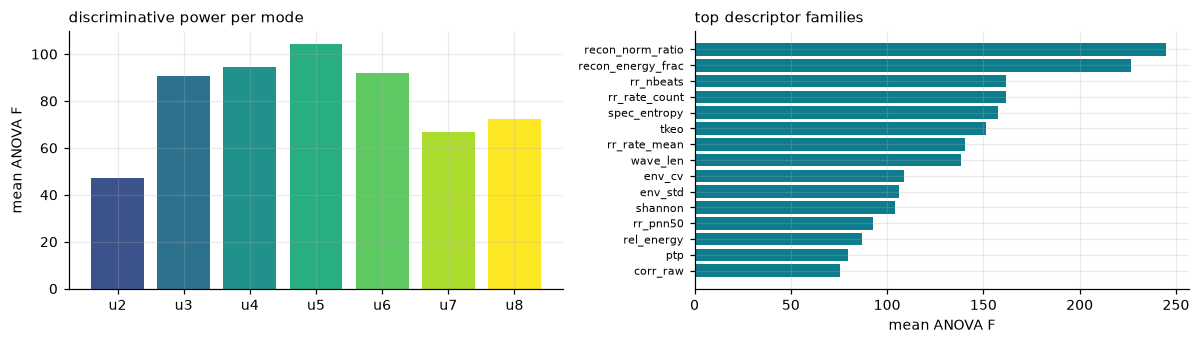

In [13]:
# Where does the discriminative power sit, mode by mode?
mode_of = np.array([int(n[1:n.index("_")]) if n.startswith("u") and n[1].isdigit() else 0
                    for n in feat_names])
by_mode = pd.Series({k: np.nanmean(F[mode_of == k]) for k in range(1, cfg.K + 1)})

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].bar([f"u{k}" for k in by_mode.index], by_mode.values,
            color=[plt.cm.viridis(k / cfg.K) for k in by_mode.index])
axes[0].set_ylabel("mean ANOVA F"); axes[0].set_title("discriminative power per mode", loc="left")

fam = {}
for n, f in zip(feat_names, F):
    key = n.split("_", 1)[1] if n.startswith("u") and n[1].isdigit() else n
    fam.setdefault(key, []).append(f)
fam_s = pd.Series({k: np.nanmean(v) for k, v in fam.items()}).sort_values(ascending=False)[:15]
axes[1].barh(range(len(fam_s)), fam_s.values[::-1], color="#0d7c8c")
axes[1].set_yticks(range(len(fam_s))); axes[1].set_yticklabels(fam_s.index[::-1], fontsize=7)
axes[1].set_xlabel("mean ANOVA F"); axes[1].set_title("top descriptor families", loc="left")
fig.tight_layout(); plt.show()

> **Be suspicious of the top-frequency mode.** If $u_K$ — centred well above the ECG
> band — is among the most discriminative, that is a warning, not a triumph. The three
> classes come from three different source databases with different amplifiers and
> anti-aliasing filters. A model can separate them on equipment fingerprint alone and
> it will not generalise to a new recording setup. Notebook 3 measures how much of the
> performance survives when that mode is removed.

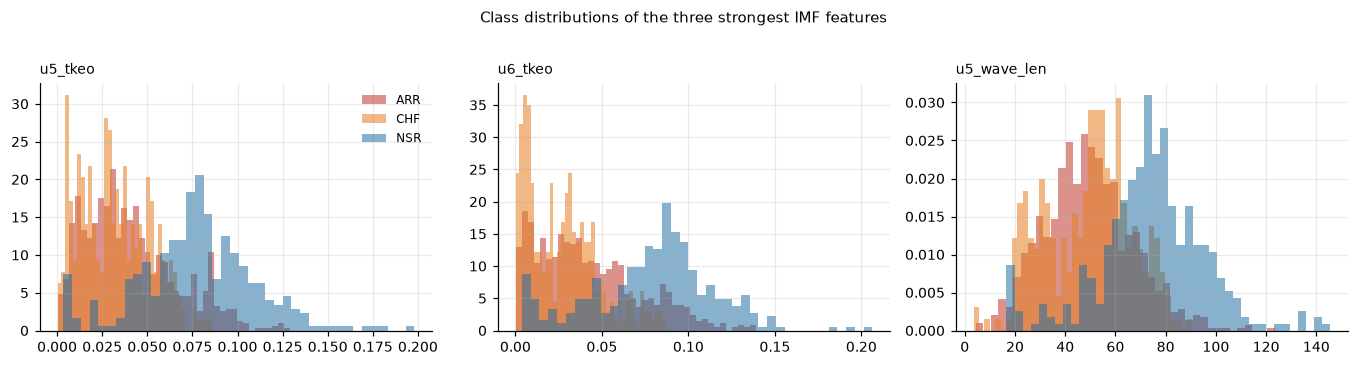

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.2))
for ax, fname in zip(axes, np.array(feat_names)[order[:3]]):
    j = feat_names.index(fname)
    for cls in CLASS_ORDER:
        ax.hist(X[y == cls, j], bins=40, alpha=0.55, density=True,
                color=CLASS_COLORS[cls], label=cls)
    ax.set_title(fname, loc="left", fontsize=9)
axes[0].legend(fontsize=8)
fig.suptitle("Class distributions of the three strongest IMF features", y=1.02, fontsize=10)
fig.tight_layout(); plt.show()

## 2.7 Save the artefact

Everything downstream loads this file. It carries the feature blocks, the labels, the
**record ids**, the iteration counts, the exact config that produced it, and optionally
the raw IMF tensor.

In [15]:
os.makedirs("features", exist_ok=True)
out = f"features/{cfg.signature()}.npz"
fb.save(out)
print(f"wrote {out}  ({os.path.getsize(out)/1e6:.1f} MB)")

# round-trip check - a saved artefact you cannot reload is not an artefact
rl = E.FeatureBundle.load(out)
assert rl["VMD modes + rhythm"][0].shape == X.shape
assert (rl.y == fb.y).all() and (rl.groups == fb.groups).all()
assert rl.cfg.alpha == cfg.alpha and rl.cfg.K == cfg.K
print("reload OK:", rl.cfg.summary())

wrote features/fixed_K8_a2000_L500_it500_eeb2053b.npz  (29.0 MB)
reload OK: fs=128 Hz | window=500 (3.91 s) | seg_mode=fixed | K=8 | alpha=2000 | dc=True | max_iter=500


---

**Next:** `03_baseline_and_quantum_prep.ipynb` — is VMD earning its cost, and reducing
236 features to something a quantum circuit can hold.